## Problem Statement

### Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).



## Objective
“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description
- The data provided is a transformed version of original data which was collected using sensors.
- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.
- Both the datasets consist of 40 predictor variables and 1 target variable

## Importing necessary libraries

In [ ]:
## Installing the libraries with the specified version.
!pip install pandas==1.5.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 imbalanced-learn==0.10.1 xgboost==2.0.3 threadpoolctl==3.3.0 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 4.0 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
blosc2 3.2.0 requires numpy>=1.26, but you have numpy 1.25.2 

In [ ]:
#pip install --upgrade scikit-learn matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

##Load the Libraries

In [ ]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

# This will help in making the Python code more structured automatically (good coding practice)
#%load_ext nb_black

## Loading the dataset

In [ ]:
original_train_df=pd.read_csv('/content/drive/MyDrive/Train.csv')
original_test_df=pd.read_csv('/content/drive/MyDrive/Test.csv')

In [ ]:
# Create a copy before any operations
train_df = original_train_df.copy()
test_df = original_test_df.copy()

## Data Overview

- Observations
- Sanity checks

###View first 5 rows





In [ ]:
train_df.head()

###View 5 last rows

In [ ]:
train_df.tail()

###View amount of rows and columns

In [ ]:
train_df.shape

- There are 20000 rows and 41 columns

###Look for duplicates

In [ ]:
#duplicates
train_df.duplicated().sum()

- There are no duplicates

###Identify missing values

In [ ]:
train_df.isnull().sum()

- There are missing values in V1 and V2.

###Statistical description of training set

In [ ]:
train_df.describe(include='all').T

###Describe data types

In [ ]:
train_df.info()

- All the predictor values are captured as a float
- The target value is captured as integer

## Exploratory Data Analysis (EDA)

### Plotting histograms and boxplots for all the variables

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Plotting all the features at one go

In [ ]:
for feature in train_df.columns:
    histogram_boxplot(train_df, feature, figsize=(12, 7), kde=False, bins=None)

- The folllowing distributions are skewed to the right: V1,V18,V27,V32 and V37.
- The following distributions are skewed to the left: V16 and V30.
- The rest of the variables have normal distributions, with outliers.
- In all the variables their are outliers to the left and right.

###Compare numerical values in a heatmap

In [ ]:
#Compare numerical values in a heatmap
#Compose matrix
corr = train_df.corr()
corr


In [ ]:
#Transfer into a heatmap
sns.heatmap(corr, annot=True, cmap='Blues')
#Enlarge size
fig = plt.gcf()
fig.set_size_inches(25,25)

-There are features that are highly correlated with each other, some positive and other negative correlations.

In [ ]:
#Check distribution of target variable
train_df['Target'].value_counts()

## Data Pre-processing

###Allocate independent and dependant variables

In [ ]:
#Create X and y
X = train_df.drop('Target', axis=1)
y = train_df['Target']

###Split the training set into train and validation sets

In [ ]:
#Split the training set into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y,random_state=1)

In [ ]:
#Distribution of X_train, X_val and X_test
print(X_train.shape, X_val.shape, test_df.shape)

## Missing value imputation




In [ ]:
#Impute the missing values
imp_mode = SimpleImputer(missing_values=np.nan, strategy="median")
# fit and transform the imputer on train data
X_train = pd.DataFrame(imp_mode.fit_transform(X_train), columns=X_train.columns)

# Transform on validation and test data
X_val = pd.DataFrame(imp_mode.transform(X_val), columns=X_val.columns)

# Prepare test data (no splitting needed)
X_test = test_df.drop('Target', axis=1)
y_test = test_df['Target']

# fit and transform the imputer on test data
X_test = pd.DataFrame(imp_mode.transform(X_test), columns=X_test.columns)

In [ ]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model.
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1

        },
        index=[0],
    )

    return df_perf

### Defining scorer to be used for cross-validation and hyperparameter tuning

- We want to reduce false negatives and will try to maximize "Recall".
- To maximize Recall, we can use Recall as a **scorer** in cross-validation and hyperparameter tuning.

In [ ]:
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Model Building with original data

##Build 7 original models and determine cross validation

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logreg", LogisticRegression(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))

##Boxplots for cross validation scores of original models

In [ ]:
# Plotting boxplots for CV scores of all models defined above

import matplotlib.pyplot as plt
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()



- XGBoost has the best cross validation score of 0.808 on train and 0.778 on validation set.
- Second is Random Forest with score of 0.719 on train and 0.743 on validation set. Gradient boost is very close.
- Fourth is Decision Tree  with score of 0.719 on train and 0.738 on validation set.


##Evaluate metrics of the 7 original models

In [ ]:


# Import necessary libraries
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
# Import necessary libraries
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Create a list with your model names and the model objects
models = []
models.append(("Logreg", LogisticRegression(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))


# Create an empty list to store results
all_metrics = []

# Evaluate each model on validation data
for name, model in models:
    model.fit(X_train, y_train)
    # Get performance metrics using validation data
    metrics = model_performance_classification_sklearn(model, X_val, y_val)

    # Add model name
    metrics['Model'] = name

    # Append to results list
    all_metrics.append(metrics)

# Combine all metrics into a single dataframe
combined_metrics = pd.concat(all_metrics, ignore_index=True)

# Set Model as index for better display
combined_metrics.set_index('Model', inplace=True)

# Display the metrics for all models
print(combined_metrics)

# Optionally, visualize the results
import matplotlib.pyplot as plt

# Plot the metrics
combined_metrics.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance on Validation Data')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

- XGBoost gives the best recall and F1 score.
- Random Forest  and GBM is second and dtree third according to recall.

# Model Building with Oversampled data


##Build 7 oversampled models and determine cross validation

In [ ]:
#Import SMOTE
from imblearn.over_sampling import SMOTE

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

In [ ]:
#Evaluate the class distribution in y_train_over
y_train_over.value_counts()

##Evaluate of 7 oversampled models with cross validation

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logreg_over", LogisticRegression(random_state=1)))
models.append(("dtree_over", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging_over", BaggingClassifier(random_state=1)))
models.append(("Random_Forest_over", RandomForestClassifier(random_state=1)))
models.append(("GBM_over", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost_over", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost_over", XGBClassifier(random_state=1, eval_metric="logloss")))

results1 = []  # Empty list to store all model's CV scores
names = ['Logreg_over','dtree_over','Bagging_over', 'Random_Forest_over','GBM_over','Adaboost_over','Xgboost_over']  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Logreg_over: 0.8812865538044636
dtree_over: 0.9732668119313808
Bagging_over: 0.9781630048735123
Random_Forest_over: 0.9856406421275405
GBM_over: 0.9239674518302545
Xgboost_over: 0.9903390573001649

Validation Performance:

Logreg_over: 0.8513513513513513
dtree_over: 0.8198198198198198
Bagging_over: 0.8423423423423423
Random_Forest_over: 0.8558558558558559
GBM_over: 0.8783783783783784
Xgboost_over: 0.8648648648648649


##Boxplot for cross validation scores of oversampled models

ValueError: The number of FixedLocator locations (6), usually from a call to set_ticks, does not match the number of labels (7).

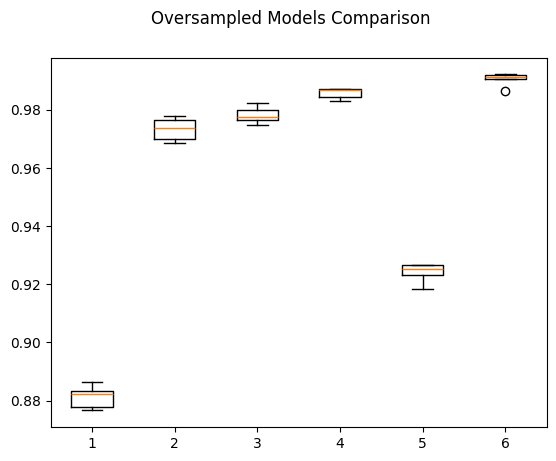

In [ ]:
# If results1 contains CV scores for oversampled models
names_oversampled = ['Logreg_over','dtree_over','Bagging_over', 'Random_Forest_over','GBM_over','Adaboost_over','Xgboost_over']

# Update the plot
fig = plt.figure()
fig.suptitle("Oversampled Models Comparison")
ax = fig.add_subplot(111)
plt.boxplot(results1)
ax.set_xticklabels(names_oversampled, rotation=90)
plt.show()

- Xgboost_over and Random_Forest_over are the top two models
- Bagging_over also performed well on the cross validation.

##Metrics of 7 oversampled models

In [ ]:


# Import necessary libraries
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
# Import necessary libraries
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Create a list with your model names and the model objects
models = []
models.append(("Logreg_over", LogisticRegression(random_state=1)))
models.append(("dtree_over", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging_over", BaggingClassifier(random_state=1)))
models.append(("Random_Forest_over", RandomForestClassifier(random_state=1)))
models.append(("GBM_over", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost_over", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost_over", XGBClassifier(random_state=1, eval_metric="logloss")))

# Create an empty list to store results1
all_metrics = []

# Evaluate each model on validation data
for name, model in models:
    model.fit(X_train_over, y_train_over)
    # Get performance metrics using validation data
    metrics = model_performance_classification_sklearn(model, X_val, y_val)

    # Add model name
    metrics['Model'] = name

    # Append to results1 list
    all_metrics.append(metrics)

# Combine all metrics into a single dataframe
combined_metrics = pd.concat(all_metrics, ignore_index=True)

# Set Model as index for better display
combined_metrics.set_index('Model', inplace=True)

# Display the metrics for all models
print(combined_metrics)

# Optionally, visualize the results1
import matplotlib.pyplot as plt

# Plot the metrics
combined_metrics.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance on Validation Data')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

- Random Forest_over gives the best recall and is the best overall model.
- XGBoost_over is second.
- Bagging_over is third with Good recall (0.812), Strong precision (0.869) and the best F1 score among the models (0.840).
- Adaboost_over is the weakest performer.
Consider the following when choosing the top model:
- If false positives are more costly, choose Random Forest (higher precision)
- If false negatives are more costly, XGBoost has slightly better recall

# Model Building with Undersampled data

In [ ]:
# Random upsampler for over sampling the data
from imblearn.under_sampling import RandomUnderSampler

# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
#Evaluate the class distribution in y_train_over
y_train_over.value_counts()

##Build 7 undersampled models and determine cross validation

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logreg_un", LogisticRegression(random_state=1)))
models.append(("dtree_un", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging_un", BaggingClassifier(random_state=1)))
models.append(("Random_Forest_un", RandomForestClassifier(random_state=1)))
models.append(("GBM_un", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost_un", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost_un", XGBClassifier(random_state=1, eval_metric="logloss")))

results2 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold
    )
    results2.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))

##Boxplots for cross validation scores of undersampled models

In [ ]:
# Plotting boxplots for CV scores of all models defined above

import matplotlib.pyplot as plt
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results2)
ax.set_xticklabels(names,rotation=90)

plt.show()



- XGBoost is the most consistent performer, showing excellent results in both cross-validation and on the validation set.
- GBM shows good generalization, with its performance on the validation set nearly matching its cross-validation score.
- Random Forest shows a drop from 0.896 in cross-validation to 0.865 on the validation set.
- Decision Tree consistently performs the worst.


##Metrics on 7 undersampled models

In [ ]:


# Import necessary libraries
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
# Import necessary libraries
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Create a list with your model names and the model objects
models = []
models.append(("Logreg_un", LogisticRegression(random_state=1)))
models.append(("dtree_un", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging_un", BaggingClassifier(random_state=1)))
models.append(("Random_Forest_un", RandomForestClassifier(random_state=1)))
models.append(("GBM_un", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost_un", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost_un", XGBClassifier(random_state=1, eval_metric="logloss")))

# Create an empty list to store results2
all_metrics = []

# Evaluate each model on validation data
for name, model in models:
    model.fit(X_train_un, y_train_un)
    # Get performance metrics using validation data
    metrics = model_performance_classification_sklearn(model, X_val, y_val)

    # Add model name
    metrics['Model'] = name

    # Append to results2 list
    all_metrics.append(metrics)

# Combine all metrics into a single dataframe
combined_metrics = pd.concat(all_metrics, ignore_index=True)

# Set Model as index for better display
combined_metrics.set_index('Model', inplace=True)

# Display the metrics for all models
print(combined_metrics)

# Optionally, visualize the results2
import matplotlib.pyplot as plt

# Plot the metrics
combined_metrics.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance on Validation Data')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

- XGBoost_un is the best overall performer with the highest recall (0.882),highest precision (0.620), highest F1 score (0.728).
- Random Forest_un is the second-best model.
- Bagging_un and GBM_un show similar performance.

Comparing the undersampling models to SMOTE:
- The SMOTE models generally achieved higher precision and F1 scores.
- XGBoost performs best in both approaches.
- Random Forest is consistently strong in both approaches.

# HyperparameterTuning

### Sample Parameter Grids

**Hyperparameter tuning can take a long time to run, so to avoid that time complexity - you can use the following grids, wherever required.**

- For Gradient Boosting:

param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}

- For Adaboost:

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

- For Bagging Classifier:

param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

- For Random Forest:

param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

- For Decision Trees:

param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

- For Logistic Regression:

param_grid = {'C': np.arange(0.1,1.1,0.1)}

- For XGBoost:

param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}

##Tuning method for XGBoost original




In [ ]:
# defining model
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics

Model = XGBClassifier(random_state=1)


# Parameter grid to pass in RandomSearchCV
param_grid = { 'n_estimators': [150, 200, 250], 'scale_pos_weight': [5,10], 'learning_rate': [0.1,0.2], 'gamma': [0,3,5], 'subsample': [0.8,0.9] }

scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

##Tuning method for XGBoost oversample


In [ ]:
# defining model
from xgboost import XGBClassifier
Model = XGBClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid={ 'n_estimators': [150, 200, 250], 'scale_pos_weight': [5,10], 'learning_rate': [0.1,0.2], 'gamma': [0,3,5], 'subsample': [0.8,0.9] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

###Tuning method for XGBoost undersample

In [ ]:
# defining model
Model = XGBClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid={ 'n_estimators': [150, 200, 250], 'scale_pos_weight': [5,10], 'learning_rate': [0.1,0.2], 'gamma': [0,3,5], 'subsample': [0.8,0.9] }

from sklearn.metrics import make_scorer, recall_score

# Define scorer - , using recall score
scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

### Tuning method for GBM oversample



In [ ]:
# defining model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": np.arange(100,150,25), "learning_rate": [0.2, 0.05, 1], "subsample":[0.5,0.7], "max_features":[0.5,0.7] }
from sklearn.metrics import make_scorer, recall_score

# Define scorer - , using recall score
scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

##Tunning method for Random Forest oversample

In [ ]:
# Import necessary libraries
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score
import numpy as np


# Apply SMOTE to oversample the minority class
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [200, 250, 300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1), "sqrt"],
    "max_samples": np.arange(0.4, 0.7, 0.1),
}

# Define scorer - , using recall score
scorer = make_scorer(recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=10,
    n_jobs=-1,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print(
    "Best parameters are {} with CV score={}:"
    .format(randomized_cv.best_params_, randomized_cv.best_score_)
)

In [ ]:
# Create model with best parameters
best_rf_over = RandomForestClassifier() #Random Forest coversampled, hypetuned model
n_estimators=300,
min_samples_leaf=1,
max_samples=0.6,


# Fit on the same training data
best_rf_over.fit(X_train_over, y_train_over)


In [ ]:
# Get predictions
rf_val_pred = best_rf.predict(X_val)

# Calculate metrics
rf_val_metrics = {
    'accuracy': accuracy_score(y_val, rf_val_pred),
    'recall': recall_score(y_val, rf_val_pred),
    'precision': precision_score(y_val, rf_val_pred),
    'f1': f1_score(y_val, rf_val_pred)
}
print (rf_val_metrics)

In [ ]:
# Create model with best parameters
best_Xgboost_over = XGBClassifier(subsample=0.8, scale_pos_weight=10, n_estimators=250, learning_rate=0.1, gamma=0)

# Fit on the same training data
best_Xgboost_over.fit(X_train_over, y_train_over)


In [ ]:
# Create model with best parameters
best_Xgboost_over = XGBClassifier(subsample=0.8, scale_pos_weight=10, n_estimators=250, learning_rate=0.1, gamma=0)

# Fit on the same training data
best_Xgboost_over.fit(X_train, y_train) # Assuming X_train and y_train are defined

# Get predictions
Xgboost_over_val_pred = best_Xgboost_over.predict(X_val)

# Calculate metrics
Xgboost_over_val_metrics = {
    'accuracy': accuracy_score(y_val, Xgboost_over_val_pred),
    'recall': recall_score(y_val, Xgboost_over_val_pred),
    'precision': precision_score(y_val, Xgboost_over_val_pred),
    'f1': f1_score(y_val, Xgboost_over_val_pred)
}
print (Xgboost_over_val_metrics)

In [ ]:
# Create model with best parameters
best_GBM_over = GradientBoostingClassifier(

)

# Fit on the same training data
best_GBM_over.fit(X_train_over, y_train_over)

In [ ]:
# Get predictions
GBM_over_val_pred = best_GBM_over.predict(X_val)
# Calculate metrics
GBM_over_val_metrics = {
    'accuracy': accuracy_score(y_val, GBM_over_val_pred),
    'recall': recall_score(y_val, GBM_over_val_pred),
    'precision': precision_score(y_val, GBM_over_val_pred),
    'f1': f1_score(y_val, GBM_over_val_pred)
}
print(GBM_over_val_metrics)
#The rest of the code remains the same.

## Model performance comparison and choosing the final model

In [ ]:
from sklearn.ensemble import (RandomForestClassifier)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
import numpy as np
import matplotlib.pyplot as plt


# Assuming X and y are your original data
# Create X and y
# X = train_df.drop('Target', axis=1) # Adjust this line if needed
# y = train_df['Target'] # Adjust this line if needed
# Split the training set into train and validation sets
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

# Initialize lists to store recall values
recall_train = []
recall_val = []
clfs = []

# Assuming you have a list of models to evaluate:
models = [
    RandomForestClassifier(n_estimators=300, random_state=1),
    XGBClassifier(learning_rate=0.1)
]

# Define feature_names here after the X_train is defined
feature_names = X_train.columns  # Get feature names from X_train

# Loop through models, fit, and calculate recall scores:
for model in models:
    model.fit(X_train, y_train)
    clfs.append(model)  # Add the fitted model to clfs
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    recall_train.append(recall_score(y_train, y_train_pred))
    recall_val.append(recall_score(y_val, y_val_pred))

# creating the model where we get highest train and val recall
index_best_model = np.argmax(recall_val)
best_model = clfs[index_best_model]

# Fit the model before using it
# best_model.fit(X_train, y_train)  # This line might be redundant if the model is already fit in the loop

importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [ ]:
# Create empty lists to store results
val_results = []

# Define your models
models = [
    ('XGBoost', best_Xgboost_over),
    ('RandomForest', best_rf_over),
    ('GBM', best_GBM_over)
]

# Calculate metrics for each model
for name, model in models:
  # Fit the model first (if it hasn't been fitted already)
    model.fit(X_train_over, y_train_over)
    # Get predictions
    y_val_pred = model.predict(X_val)

    # Calculate metrics
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_recall = recall_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    # Append results
    val_results.append({
        'Model': name,
        'Val Accuracy': val_accuracy,
        'Val Recall': val_recall,
        'Val Precision': val_precision,
        'Val F1': val_f1
    })

# Create DataFrame
models_val_comp_df = pd.DataFrame(val_results).set_index('Model')
print("Validation performance comparison:")
print(models_val_comp_df)

- Simplicity and maximizing recall are my main concerns in the project, therefor the Gradient Boosting Oversampled Hypertuned Machine model is my first choice.

### Test set final performance

In [ ]:
#Test performance of Gradientboost, oversampled , hypertuned model
Test_Score = model_performance_classification_sklearn(best_GBM_over, X_test, y_test)
print("Final Model performance on Test Dataset:")
Test_Score

## Pipelines to build the final model


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Create an imblearn Pipeline that includes oversampling
Final_pipeline_model = ImbPipeline(
    steps=[
        ("imputer", SimpleImputer()),
        ("sampler", SMOTE(random_state=42)),
        (
            "best_GBM_over",
            GradientBoostingClassifier(
                subsample=0.7, n_estimators=125, max_features=0.5, learning_rate=1
            ),
        ),
    ]
)

# Fit the model on training data
Final_pipeline_model.fit(X_train, y_train)

# Calculating different metrics on test set
Test_Score = model_performance_classification_sklearn(Final_pipeline_model, X_test, y_test)
print("Final Model performance on Test Dataset:")
print(Test_Score)

In [ ]:
#Show confusion mstrix for model and visually illustrate
from sklearn.metrics import confusion_matrix
y_pred = Final_pipeline_model.predict(X_test)
confusion_matrix(y_test, y_pred)

In [ ]:
#Plot confusion matrix to show true positive, false positive, true negative and false negative values
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")



In [ ]:
confusion_matrix_sklearn(Final_pipeline_model, X_test, y_test)

In [ ]:
# Print the key metrics for recommendations
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
print(f"False Negative Rate: {fn/(fn+tp):.2%}")
print(f"False Positive Rate: {fp/(fp+tn):.2%}")

# Business Insights and Conclusions

###Model performance metrics

- The Gradientboost, oversampled, hypertuned model can identify 82.6% of all positive cases (recall).
- When the model flags something as positive, it's correct 66.8% of the time (precision).
- The  model achieves 96.7% overall accuracy.

###Importance features

- The ten most importance features in descending order are :
V18,V21,V10,V25,V39, V9,V11,V3,V22,V26 and V36.
- V18 is at the highest relative importance of 0.2.
- V21 is at a relative importance of 0.05. There after the importances decreases gradually.

###Importance of recall

- The false negative rate is low at 14.89%, thus the prediction of a faulty turbine as functioning normally will be limited. This will save replacing costs.
- The false positive rate is 3% and will result in inspection costs which are less expensive than repairing or replacing costs.


###Business recommendations

- Use the model's 82.6% recall rate to identify most turbines at risk of failure before they break down.
- Schedule maintenance for high-risk turbines during low-wind periods to minimize production loss.
- Reduce unnecessary preventive maintenance on turbines with low failure probability.
- Pre-position spare parts near turbine clusters with elevated failure predictions.
- Analyze which features (sensor data points) contribute most to prediction accuracy.
- Consider upgrading or adding sensors related to the most predictive features.
- Reduce investment in sensors that provide minimal predictive value.
- Incorporate model predictions into operations dashboards for real-time
monitoring.
- Develop emergency response protocols for sudden high-risk predictions.
- Create feedback loops between maintenance reports and model training.

***